Dataset Preview
   Temperature  Vibration  Pressure  Humidity  Machine_Failure
0           62         72        88        69                1
1           73         80        96        77                1
2           69         33        67        79                0
3           40         12        46        82                0
4           61         71        65        58                1

Model Accuracy: 1.0

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         6

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10


Enter Machine Details


Temperature:  45
Vibration Level:  45
Pressure:  25
Humidity:  60



Machine Working Normally
Prediction Probability: [[0.92 0.08]]


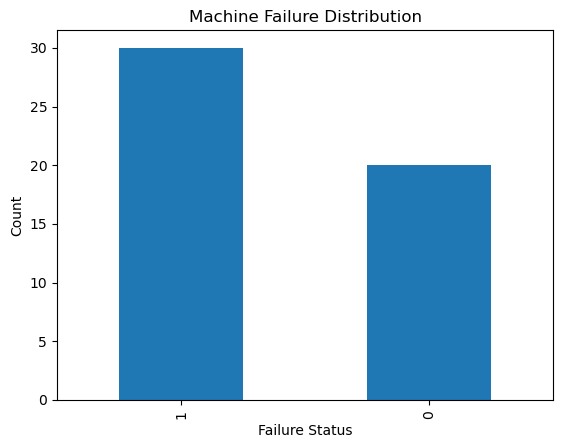

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

data = pd.read_csv("machine_data.csv")

print("Dataset Preview")
print(data.head())

X = data.drop("Machine_Failure", axis=1)
y = data["Machine_Failure"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("\nModel Accuracy:", accuracy)

print("\nClassification Report")
print(classification_report(y_test, predictions))

print("\nEnter Machine Details")

temperature = float(input("Temperature: "))
vibration = float(input("Vibration Level: "))
pressure = float(input("Pressure: "))
humidity = float(input("Humidity: "))

user_data = pd.DataFrame([[
    temperature,
    vibration,
    pressure,
    humidity
]], columns=[
    "Temperature",
    "Vibration",
    "Pressure",
    "Humidity"
])

prediction = model.predict(user_data)

probability = model.predict_proba(user_data)

if prediction[0] == 1:
    print("\nMachine Failure Predicted")
    print("Maintenance Required Immediately")
else:
    print("\nMachine Working Normally")

print("Prediction Probability:", probability)

data["Machine_Failure"].value_counts().plot(kind="bar")

plt.title("Machine Failure Distribution")
plt.xlabel("Failure Status")
plt.ylabel("Count")

plt.show()